
# A* Search — A Step‑by‑Step, Colab‑Ready Notebook
**Last updated:** 2025-10-07 22:31

This notebook develops A* from first principles, moving from problem formulation to a clean, reusable implementation.
It includes an instrumented version for pedagogical tracing, multiple heuristics, and two worked examples: a small weighted graph and a 2D grid world.

**Learning objectives**
- Understand the evaluation function \(f(n) = g(n) + h(n)\) and the roles of \(g\)-costs and the heuristic \(h\).
- Implement A* with a priority queue (min-heap) and a closed set.
- Verify heuristic **admissibility** and **consistency**, and observe their effects.
- Visualize solutions on both graphs and grids; compare with Dijkstra (\(h=0\)).
- Explore variants (e.g., Weighted A*) and practical tie-breaking strategies.

> **How to use**: Run cells top-to-bottom. Toggle `DEBUG=True` in the A* call to see a step-by-step trace.



## Background and Pseudocode

**A\*** maintains a frontier of *partial* paths prioritized by an estimate of total solution cost
\(
f(n) = g(n) + h(n)
\), where:
- \(g(n)\) is the cost of the best path found so far from the start to \(n\).
- \(h(n)\) is a heuristic estimate of the cheapest path from \(n\) to a goal.

If \(h\) is **admissible** (never overestimates true remaining cost) and **consistent** (monotone), A\* with a graph-search closed set is **optimal** and **complete** on finite graphs with positive edge costs.

**High-level pseudocode (graph search):**
```
function A*(start, is_goal, neighbors, cost, h):
    open := priority queue ordered by f = g + h
    push start with g(start)=0
    came_from := map to reconstruct paths
    g_score[start] := 0
    closed := empty set

    while open not empty:
        n := pop node with smallest f
        if is_goal(n): return reconstruct(came_from, n)

        if n in closed: continue
        add n to closed

        for each (m) in neighbors(n):
            tentative_g := g_score[n] + cost(n, m)
            if m not seen or tentative_g < g_score[m]:
                came_from[m] := n
                g_score[m] := tentative_g
                f := tentative_g + h(m)
                push/update m in open with priority f

    return failure
```
**Complexity (worst case)**: exponential in the search depth for arbitrary graphs; with a good heuristic, node expansions drop dramatically. Memory is \(O(b^d)\) due to the frontier and closed set.



## Core A* Implementation (Reusable)

We implement a reusable A* that accepts *callables* for goal testing, neighbors, cost, and heuristic. It includes an optional `debug` flag for pedagogical tracing and a stable tie-breaker to avoid heap comparison issues.


In [1]:

from typing import Any, Callable, Dict, Hashable, Iterable, List, Optional, Tuple
import heapq
import math
import time
from dataclasses import dataclass, field

@dataclass(order=True)
class _PQItem:
    priority: float
    tiebreak: int
    node: Any=field(compare=False)

def reconstruct_path(came_from: Dict[Hashable, Hashable], goal: Hashable) -> List[Hashable]:
    path = [goal]
    while path[-1] in came_from:
        path.append(came_from[path[-1]])
    path.reverse()
    return path

def astar(
    start: Hashable,
    is_goal: Callable[[Hashable], bool],
    neighbors: Callable[[Hashable], Iterable[Hashable]],
    cost: Callable[[Hashable, Hashable], float],
    h: Callable[[Hashable], float],
    debug: bool=False,
) -> Tuple[Optional[List[Hashable]], Dict[str, Any]]:
    """
    A* graph search.
    Returns (path, info). If no path, path=None. 'info' contains diagnostics.
    """
    counter = 0
    open_heap: List[_PQItem] = []
    came_from: Dict[Hashable, Hashable] = {}
    g: Dict[Hashable, float] = {start: 0.0}
    closed: set = set()

    def push(node, priority):
        nonlocal counter
        heapq.heappush(open_heap, _PQItem(priority, counter, node))
        counter += 1

    push(start, h(start))

    expansions = 0
    pushes = 1
    t0 = time.perf_counter()

    while open_heap:
        current_item = heapq.heappop(open_heap)
        n = current_item.node
        f_n = current_item.priority
        if n in closed:
            # Stale entry — skip
            if debug:
                print(f"[skip] {n} (stale)")
            continue

        if debug:
            print(f"[pop] {n} with f={f_n:.3f}, g={g[n]:.3f}, h={h(n):.3f}")

        if is_goal(n):
            t1 = time.perf_counter()
            path = reconstruct_path(came_from, n)
            return path, {
                "expanded": expansions,
                "pushed": pushes,
                "time_sec": t1 - t0,
                "cost": g[n],
                "closed_size": len(closed),
            }

        closed.add(n)
        expansions += 1

        for m in neighbors(n):
            c = cost(n, m)
            if c < 0:
                raise ValueError("Negative edge cost encountered; A* requires nonnegative costs.")
            tentative_g = g[n] + c

            if m in g and tentative_g >= g[m]:
                if debug:
                    print(f"  [relax? no] {n} -> {m} (g'={tentative_g:.3f} >= g[m]={g[m]:.3f})")
                continue

            came_from[m] = n
            g[m] = tentative_g
            f_m = tentative_g + h(m)
            push(m, f_m)
            pushes += 1
            if debug:
                print(f"  [relax yes] {n} -> {m}  g={tentative_g:.3f}, h={h(m):.3f}, f={f_m:.3f}")

    # No solution
    return None, {
        "expanded": expansions,
        "pushed": pushes,
        "time_sec": time.perf_counter() - t0,
        "cost": math.inf,
        "closed_size": len(closed),
    }



## Heuristic Admissibility and Consistency Checks

We include helpers to (a) estimate admissibility via sampling and (b) verify **consistency** given explicit edge lists.
Consistency (monotonicity) is checkable from edges: for all edges \(u\to v\) with cost \(c(u,v)\), require
\(
h(u) \le c(u,v) + h(v).
\)


In [2]:

from typing import Iterable, Tuple

def check_consistency(
    nodes: Iterable[Hashable],
    out_edges: Callable[[Hashable], Iterable[Tuple[Hashable, float]]],
    h: Callable[[Hashable], float],
    atol: float = 1e-9
) -> Tuple[bool, List[Tuple[Hashable, Hashable, float, float, float]]]:
    """
    Returns (is_consistent, violations), where each violation is (u, v, c, hu, hv).
    """
    violations = []
    for u in nodes:
        hu = h(u)
        for v, c in out_edges(u):
            hv = h(v)
            if hu - (c + hv) > atol:
                violations.append((u, v, c, hu, hv))
    return len(violations) == 0, violations



## Example 1 — Small Weighted Graph (with coordinates)

We build a small undirected weighted graph with 2D coordinates and use **Euclidean** \(h\), which is admissible for straight-line distances when edge weights are Euclidean lengths (or upper bounds thereof). Compare A* to Dijkstra by setting \(h \equiv 0\).


In [3]:

# Define a small graph
import math

coords = {
    "A": (0, 0),
    "B": (1, 2),
    "C": (3, 1),
    "D": (4, 3),
    "E": (6, 0),
    "F": (7, 2),
}
edges_undirected = {
    "A": {"B": 2.3, "C": 3.2},
    "B": {"A": 2.3, "C": 2.0, "D": 2.2},
    "C": {"A": 3.2, "B": 2.0, "D": 2.4, "E": 3.1},
    "D": {"B": 2.2, "C": 2.4, "F": 2.1},
    "E": {"C": 3.1, "F": 2.0},
    "F": {"D": 2.1, "E": 2.0},
}

def neighbors_graph(u):
    return edges_undirected[u].keys()

def cost_graph(u, v):
    return edges_undirected[u][v]

goal = "F"
def is_goal_graph(n): return n == goal

def h_euclid(n):
    (x, y) = coords[n]
    (gx, gy) = coords[goal]
    return math.hypot(x - gx, y - gy)

def h_zero(_): return 0.0

print("=== A* with Euclidean heuristic ===")
path_h, info_h = astar("A", is_goal_graph, neighbors_graph, cost_graph, h_euclid, debug=True)
print("\nPath:", path_h, "\nInfo:", info_h)

print("\n=== Dijkstra (A* with h=0) ===")
path_d, info_d = astar("A", is_goal_graph, neighbors_graph, cost_graph, h_zero, debug=False)
print("Path:", path_d, "\nInfo:", info_d)


=== A* with Euclidean heuristic ===
[pop] A with f=7.280, g=0.000, h=7.280
  [relax yes] A -> B  g=2.300, h=6.000, f=8.300
  [relax yes] A -> C  g=3.200, h=4.123, f=7.323
[pop] C with f=7.323, g=3.200, h=4.123
  [relax? no] C -> A (g'=6.400 >= g[m]=0.000)
  [relax? no] C -> B (g'=5.200 >= g[m]=2.300)
  [relax yes] C -> D  g=5.600, h=3.162, f=8.762
  [relax yes] C -> E  g=6.300, h=2.236, f=8.536
[pop] B with f=8.300, g=2.300, h=6.000
  [relax? no] B -> A (g'=4.600 >= g[m]=0.000)
  [relax? no] B -> C (g'=4.300 >= g[m]=3.200)
  [relax yes] B -> D  g=4.500, h=3.162, f=7.662
[pop] D with f=7.662, g=4.500, h=3.162
  [relax? no] D -> B (g'=6.700 >= g[m]=2.300)
  [relax? no] D -> C (g'=6.900 >= g[m]=3.200)
  [relax yes] D -> F  g=6.600, h=0.000, f=6.600
[pop] F with f=6.600, g=6.600, h=0.000

Path: ['A', 'B', 'D', 'F'] 
Info: {'expanded': 4, 'pushed': 7, 'time_sec': 0.00018377700001792618, 'cost': 6.6, 'closed_size': 4}

=== Dijkstra (A* with h=0) ===
Path: ['A', 'B', 'D', 'F'] 
Info: {'expand

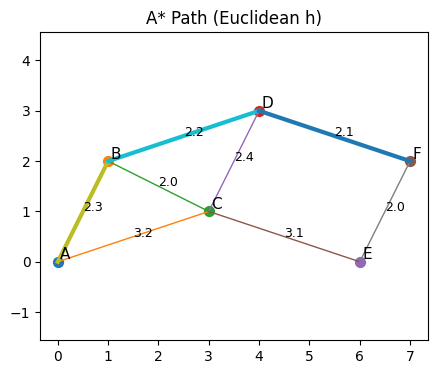

In [4]:

import matplotlib.pyplot as plt

def draw_graph_path(coords, edges, path=None, title="Graph and Path"):
    plt.figure(figsize=(5,4))
    # Draw edges
    for u, nbrs in edges.items():
        x1, y1 = coords[u]
        for v, w in nbrs.items():
            if u < v:  # draw undirected once
                x2, y2 = coords[v]
                plt.plot([x1, x2], [y1, y2], linewidth=1)
                xm, ym = (x1+x2)/2, (y1+y2)/2
                plt.text(xm, ym, f"{w:.1f}", fontsize=9)
    # Draw nodes
    for n, (x, y) in coords.items():
        plt.scatter([x], [y], s=50)
        plt.text(x+0.05, y+0.05, n, fontsize=11)
    # Draw path
    if path:
        for u, v in zip(path, path[1:]):
            x1, y1 = coords[u]
            x2, y2 = coords[v]
            plt.plot([x1, x2], [y1, y2], linewidth=3)
    plt.title(title)
    plt.axis("equal")
    plt.show()

draw_graph_path(coords, edges_undirected, path_h, title="A* Path (Euclidean h)")



## Example 2 — 2D Grid World (4-connected)

We consider a binary occupancy grid with 4-connected moves (N/E/S/W), unit step cost, and **Manhattan** heuristic:
\(
h(x,y) = |x-x_g| + |y-y_g|
\)
which is both admissible and consistent in this setting.


In [5]:

import numpy as np
import random

def make_grid(w=20, h=12, obstacle_prob=0.20, seed=7):
    rng = random.Random(seed)
    grid = np.zeros((h, w), dtype=np.int8)
    for y in range(h):
        for x in range(w):
            if rng.random() < obstacle_prob:
                grid[y, x] = 1  # obstacle
    return grid

def grid_neighbors(grid, cell):
    y, x = cell
    H, W = grid.shape
    for dy, dx in [(-1,0), (1,0), (0,-1), (0,1)]:  # 4-connected
        ny, nx = y+dy, x+dx
        if 0 <= ny < H and 0 <= nx < W and grid[ny, nx] == 0:
            yield (ny, nx)

def grid_cost(_u, _v):  # unit cost
    return 1.0

def manhattan(cell, goal):
    (y, x), (gy, gx) = cell, goal
    return abs(y - gy) + abs(x - gx)

# Build grid and ensure start/goal are free
grid = make_grid(w=28, h=18, obstacle_prob=0.22, seed=13)
start, goal = (1, 1), (grid.shape[0]-2, grid.shape[1]-3)
grid[start] = 0
grid[goal] = 0

def is_goal_cell(c): return c == goal
def h_manhattan(c): return float(manhattan(c, goal))

path_grid, info_grid = astar(
    start=start,
    is_goal=is_goal_cell,
    neighbors=lambda c: grid_neighbors(grid, c),
    cost=grid_cost,
    h=h_manhattan,
    debug=False
)

print("Path length:", None if path_grid is None else len(path_grid)-1)
print("Info:", info_grid)


Path length: 39
Info: {'expanded': 192, 'pushed': 237, 'time_sec': 0.0014564150000069276, 'cost': 39.0, 'closed_size': 192}


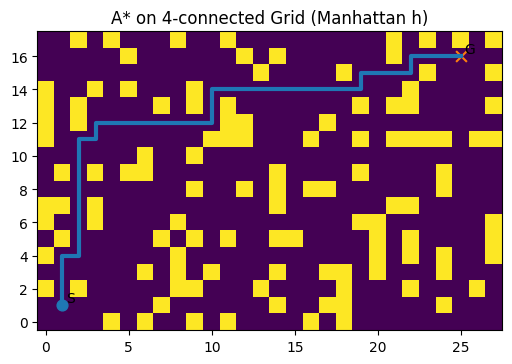

In [6]:

def show_grid_path(grid, path=None, start=None, goal=None, title="Grid and Path"):
    import matplotlib.pyplot as plt
    H, W = grid.shape
    plt.figure(figsize=(6,5))
    plt.imshow(grid, origin="upper")
    if path:
        ys = [y for (y, x) in path]
        xs = [x for (y, x) in path]
        plt.plot(xs, ys, linewidth=3)
    if start:
        plt.scatter([start[1]], [start[0]], s=60, marker="o")
        plt.text(start[1]+0.2, start[0]+0.2, "S")
    if goal:
        plt.scatter([goal[1]], [goal[0]], s=60, marker="x")
        plt.text(goal[1]+0.2, goal[0]+0.2, "G")
    plt.title(title)
    plt.gca().invert_yaxis()  # draw (0,0) at top-left
    plt.show()

show_grid_path(grid, path_grid, start, goal, "A* on 4-connected Grid (Manhattan h)")


In [7]:

# Build explicit edge iterator for a consistency check on a subset of nodes (for speed)
H, W = grid.shape
def out_edges(cell):
    for nbr in grid_neighbors(grid, cell):
        yield (nbr, 1.0)

# Sample nodes set (all free cells) — this can be large; we subsample for speed
free_cells = [(y, x) for y in range(H) for x in range(W) if grid[y, x] == 0]
sample = free_cells[::max(1, len(free_cells)//1000)]  # at most ~1000 cells

consistent, violations = check_consistency(sample, out_edges, h=lambda c: manhattan(c, goal))
print("Manhattan heuristic consistent on sample subset?", consistent)
print("Number of violations found:", len(violations))


Manhattan heuristic consistent on sample subset? True
Number of violations found: 0



## Variants and Practical Details

- **Weighted A\***: replace \(f = g + h\) with \(f = g + w\,h\) (with \(w \ge 1\)). Larger \(w\) speeds up search but sacrifices optimality.
- **Tie-breaking**: when multiple nodes have the same \(f\), favor larger \(g\) to push search deeper along promising paths; implemented by adjusting the `tiebreak` order.
- **8-connected grids**: use the **octile** heuristic \(h = (\max(dx,dy)) + (\sqrt{2}-1)\min(dx,dy)\) with diagonal move cost \(\sqrt{2}\).
- **Dijkstra**: A\* with \(h \equiv 0\).
- **IDA\***: iterative deepening A\* reduces memory at the cost of re-expansions.


In [14]:

def astar_weighted(
    start,
    is_goal,
    neighbors,
    cost,
    h,
    weight: float = 1.0,
    debug: bool = False
):
    """
    Weighted A* — scales the heuristic by 'weight' (>=1.0).
    """
    def h_scaled(n):
        return weight * h(n)
    return astar(start, is_goal, neighbors, cost, h_scaled, debug=debug)


## Micro-benchmark

A tiny experiment to illustrate how increasing obstacle density and heuristic weighting affect expansions. This is **not** a rigorous benchmark; it only serves to give intuition.


In [15]:

def run_trial(W=40, H=28, p=0.22, w=1.0, seed=0):
    grid = make_grid(W, H, p, seed)
    start, goal = (1,1), (H-2, W-3)
    grid[start] = 0; grid[goal] = 0
    def h_m(c): return manhattan(c, goal)
    path, info = astar_weighted(
        start, lambda c: c==goal, lambda c: grid_neighbors(grid, c), grid_cost, h_m, weight=w
    )
    return (path is not None), (None if path is None else len(path)-1), info["expanded"], info["time_sec"]

for p in [0.15, 0.22, 0.30]:
    for w in [1.0, 1.2, 1.5]:
        ok, plen, expanded, t = run_trial(p=p, w=w, seed=42)
        print(f"p={p:.2f}, w={w:.1f}  ->  solved={ok}, path_len={plen}, expanded={expanded}, time={t*1000:.1f} ms")


p=0.15, w=1.0  ->  solved=True, path_len=61, expanded=646, time=3.9 ms
p=0.15, w=1.2  ->  solved=True, path_len=65, expanded=165, time=1.7 ms
p=0.15, w=1.5  ->  solved=True, path_len=71, expanded=126, time=1.0 ms
p=0.22, w=1.0  ->  solved=True, path_len=61, expanded=375, time=2.2 ms
p=0.22, w=1.2  ->  solved=True, path_len=67, expanded=162, time=1.2 ms
p=0.22, w=1.5  ->  solved=True, path_len=69, expanded=127, time=1.1 ms
p=0.30, w=1.0  ->  solved=True, path_len=67, expanded=397, time=2.2 ms
p=0.30, w=1.2  ->  solved=True, path_len=67, expanded=193, time=1.2 ms
p=0.30, w=1.5  ->  solved=True, path_len=73, expanded=133, time=0.8 ms



## Exercises / Extensions

1. **Tie-breaking strategy**: Modify the A\* implementation to *prefer larger \(g\)* on equal \(f\). Does it reduce expansions on your grids?
2. **8-connected movement**: Allow diagonal moves at cost \(\sqrt{2}\); implement the **octile** heuristic and compare to Manhattan on the same maps.
3. **Heuristic design**: Craft an **inadmissible** heuristic (e.g., \(h' = 1.2\,h\)) and demonstrate suboptimal paths; quantify the suboptimality factor.
4. **Consistency verifier**: For the small graph in Example 1, programmatically verify consistency and then slightly **perturb edge costs** to construct a counterexample.
5. **IDA\***: Implement Iterative Deepening A\* (IDA\*) and compare memory usage and expansions on hard instances.
6. **Landmarks**: For large grids, experiment with **landmark-based** heuristics (ALT) and compare against Manhattan.
7. **Anytime A\*** (ARA\*): Start with \(w>1\) and decrease towards 1, producing improving solutions under time budgets.



## Sanity Test

Re-run the small graph with `h=0` and verify that the returned path matches the A* with admissible heuristic's cost.


In [17]:

# Reset graph goal; avoid clash with grid's 'goal' tuple.
goal = "F"
def is_goal_graph(n): return n == goal
def h_euclid(n):
    (x, y) = coords[n]
    (gx, gy) = coords[goal]
    return math.hypot(x - gx, y - gy)

ph, ih = path_h, info_h
p0, i0 = astar("A", is_goal_graph, neighbors_graph, cost_graph, h_zero, debug=False)
print("Costs equal?", abs(ih["cost"] - i0["cost"]) < 1e-9, " | cost(A*,h):", ih["cost"], " cost(Dijkstra):", i0["cost"])


Costs equal? True  | cost(A*,h): 6.6  cost(Dijkstra): 6.6
